# **MainQuest 05: House Prices Prediction**

<br>

## **I. 프로젝트 개요**

---

### **가이드라인 (Notion)**

#### **메인퀘스트: House Price Prediction**

- 데이터 사이언티스트로써, 다음 [캐글 Competition](https://www.kaggle.com/t/531966d5a15f468993fe2d56bd763380) 으로 이동하여 

- Ames 시 주택 가격을 예측하는 모델을 만들어 더 좋은 의사결정을 해 봅시다!

#### 대회 Overview:

- 예측할 값(y): `SalePrice`

- 모델 평가 지표 : `RMSE` (Root mean sqaured error)

- 진행 방식
    1. Code 란에서 테스트 노트북을 Copy&Edit 하여 작업!
    2. 테스트 노트북을 submit 하여 리더보드에 정상적으로 등록되는지 확인하기
    3. 자유롭게 모델을 발전시켜 좋은 성적 거두기!
    4. 정상적으로 submit하고, 다음 구글폼에 이름/노트북주소/닉네임 등록!!!

#### **퀘스트 평가 기준: 각 1점**

- 데이터 이해 및 탐색 : SalePrice와 주요 변수들의 분포를 시각화를 통해서 파악했는가?

- 데이터 전처리 과정 : 결측치 및 이상치를 처리하고 스케일링 및 인코딩을 적절히 수행했는가?

- 모델 선택 및 비교 : 3개 이상의 모델을 학습시키고 성능 비교했는가?

- 여러 모델을 앙상블을 통해 결합하여 성능을 비교했는가?

- Ridge/Lasso 등의 규제 추가, 트리 기반 모델의 깊이/학습률 등을 조정하여 성능 향상을 시도했는가?

<br>

### **Kaggle Competition Overview**

#### **미션**

- [회귀] 주택 가격 예측

- 예측할 값(y): SalePrice

- 평가지표: RMSE

#### **평가지표**

- 데이터 이해 및 탐색 : SalePrice와 주요 변수들의 분포를 시각화를 통해서 파악했는가?

- 데이터 전처리 과정 : 결측치 및 이상치를 처리하고 스케일링 및 인코딩을 적절히 수행했는가?

- 모델 선택 및 비교 : 3개 이상의 모델을 학습시키고 성능 비교했는가?

- 여러 모델을 앙상블을 통해 결합하여 성능을 비교했는가?

- Ridge/Lasso 등의 규제 추가, 트리 기반 모델의 깊이/학습률 등을 조정하여 성능 향상을 시도했는가?

<br><br>

## **II. 프로젝트 수행**

---

### **TASK 0. Setup + Load**

In [3]:
# Setup

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

SEED = 42
np.random.seed(SEED)

In [2]:
# Data Load

In [4]:
DATA_DIR = Path("./data/house")  

train_path = DATA_DIR / "train.csv"
test_path  = DATA_DIR / "test.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print("train shape:", train.shape)
print("test  shape:", test.shape)

train shape: (1168, 81)
test  shape: (292, 80)


In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,968,20,RL,NaN,7390,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,7,1955,1955,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,151.0,TA,TA,CBlock,TA,TA,No,ALQ,902,Unf,0,196,1098,GasA,TA,Y,SBrkr,1098,0,0,1098,1,0,1,0,3,1,TA,6,Typ,0,NaN,Attchd,1955.0,Unf,1,260,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal,135000
1,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,5,5,1987,1988,Gable,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,Gd,Gd,Gd,GLQ,1200,Unf,0,0,1200,GasA,TA,Y,SBrkr,1200,0,0,1200,3,0,3,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,120,0,0,0,0,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000
2,696,20,RL,54.0,13811,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,6,6,1987,1987,Gable,CompShg,HdBoard,HdBoard,BrkFace,72.0,TA,TA,CBlock,Gd,Gd,No,GLQ,980,LwQ,40,92,1112,GasA,Gd,Y,SBrkr,1137,0,0,1137,1,0,2,0,2,1,Gd,5,Typ,1,TA,Attchd,1987.0,Unf,2,551,TA,TA,Y,125,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,176000
3,239,20,RL,93.0,12030,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,BrkFace,254.0,Ex,TA,PConc,Ex,TA,No,Unf,0,Unf,0,1694,1694,GasA,Ex,Y,SBrkr,1694,0,0,1694,0,0,2,0,3,1,Gd,7,Typ,0,NaN,Attchd,2007.0,Fin,3,818,TA,TA,Y,168,228,0,0,0,0,NaN,NaN,NaN,0,12,2007,New,Partial,318000
4,891,50,RL,60.0,8064,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,1.5Fin,5,7,1949,2006,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,CBlock,TA,TA,Mn,Unf,0,Unf,0,672,672,GasA,Ex,Y,SBrkr,672,252,0,924,0,0,1,0,3,1,TA,6,Typ,1,Po,Detchd,2003.0,Unf,2,576,TA,TA,Y,0,0,0,0,0,0,NaN,MnPrv,Shed,2000,7,2007,WD,Normal,122900


<br>

### **TASK 1. Basic Checks**

In [15]:
# Target 확인

In [16]:
assert "SalePrice" in train.columns
assert "SalePrice" not in test.columns

In [17]:
y_raw = train["SalePrice"].copy()
y_log = np.log1p(y_raw)

In [18]:
print("y_raw describe:")
display(y_raw.describe())

print("\ny_log describe:")
display(pd.Series(y_log).describe())

y_raw describe:


count      1168.000000
mean     180194.401541
std       78869.201529
min       34900.000000
25%      129500.000000
50%      163995.000000
75%      213062.500000
max      755000.000000
Name: SalePrice, dtype: float64


y_log describe:


count    1168.000000
mean       12.020568
std         0.398863
min        10.460271
25%        11.771444
50%        12.007597
75%        12.269345
max        13.534474
Name: SalePrice, dtype: float64

In [19]:
# ID 중복 체크

In [20]:
assert "Id" in train.columns and "Id" in test.columns

In [21]:
train_ids = train["Id"].copy()
test_ids  = test["Id"].copy()

In [22]:
print("\nId checks:")
print("train Id unique:", train_ids.is_unique, "| n:", len(train_ids))
print("test  Id unique:", test_ids.is_unique,  "| n:", len(test_ids))


Id checks:
train Id unique: True | n: 1168
test  Id unique: True | n: 292


In [23]:
# 타입 체크

In [24]:
print("\n[train dtypes counts]")
display(train.dtypes.value_counts())

print("\n[test dtypes counts]")
display(test.dtypes.value_counts())


[train dtypes counts]


object     43
int64      35
float64     3
Name: count, dtype: int64


[test dtypes counts]


object     43
int64      34
float64     3
Name: count, dtype: int64

In [25]:
# 결측 체크

In [26]:
print("\n[train missing top 30]")
display(train.isna().sum().sort_values(ascending=False).head(30))

print("\n[test missing top 30]")
display(test.isna().sum().sort_values(ascending=False).head(30))


[train missing top 30]


PoolQC          1162
MiscFeature     1120
Alley           1098
Fence            941
MasVnrType       694
FireplaceQu      545
LotFrontage      218
GarageYrBlt       69
GarageCond        69
GarageType        69
GarageFinish      69
GarageQual        69
BsmtFinType2      24
BsmtExposure      24
BsmtQual          23
BsmtCond          23
BsmtFinType1      23
MasVnrArea         8
Electrical         1
Id                 0
Functional         0
Fireplaces         0
KitchenQual        0
KitchenAbvGr       0
BedroomAbvGr       0
HalfBath           0
FullBath           0
BsmtHalfBath       0
TotRmsAbvGrd       0
GarageCars         0
dtype: int64


[test missing top 30]


PoolQC          291
MiscFeature     286
Alley           271
Fence           238
MasVnrType      178
FireplaceQu     145
LotFrontage      41
BsmtFinType1     14
BsmtQual         14
BsmtCond         14
BsmtFinType2     14
BsmtExposure     14
GarageType       12
GarageYrBlt      12
GarageQual       12
GarageCond       12
GarageFinish     12
KitchenQual       0
Functional        0
BedroomAbvGr      0
HalfBath          0
FullBath          0
TotRmsAbvGrd      0
BsmtHalfBath      0
BsmtFullBath      0
GrLivArea         0
KitchenAbvGr      0
Id                0
Fireplaces        0
2ndFlrSF          0
dtype: int64

In [27]:
# 타깃 분포 시각화 (원본/로그)

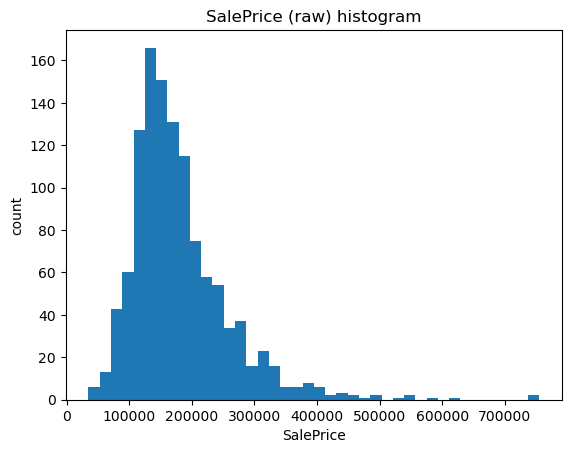

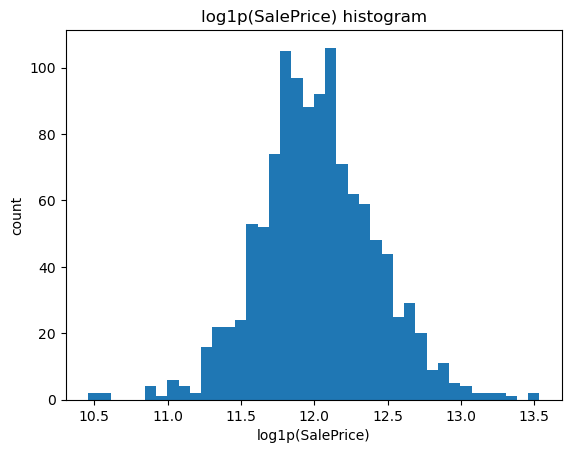

In [28]:
plt.figure()
plt.hist(y_raw, bins=40)
plt.title("SalePrice (raw) histogram")
plt.xlabel("SalePrice")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(y_log, bins=40)
plt.title("log1p(SalePrice) histogram")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("count")
plt.show()

<br>

### **TASK 2. EDA**

#### **Feature grouping (semantic groups)**

In [33]:
# Train/test feature columns mismatch check

In [32]:
TARGET = "SalePrice"
IDCOL = "Id"

all_cols = [c for c in train.columns if c not in [TARGET]]
all_cols_test = list(test.columns)

assert set(all_cols) == set(all_cols_test), "train/test feature columns mismatch!"

In [30]:
# 그룹 정의 (Ames Housing 대표적인 의미 그룹)

In [31]:
grp_location = ["Neighborhood", "Condition1", "Condition2"]

grp_lot = ["MSZoning", "LotFrontage", "LotArea", "Street", "Alley", "LotShape",
           "LandContour", "Utilities", "LotConfig", "LandSlope"]

grp_building = ["MSSubClass", "BldgType", "HouseStyle", "OverallQual", "OverallCond",
                "YearBuilt", "YearRemodAdd"]

grp_roof_ext = ["RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd",
                "MasVnrType", "MasVnrArea", "ExterQual", "ExterCond", "Foundation"]

grp_basement = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinSF1",
                "BsmtFinType2", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF"]

grp_heating_elec = ["Heating", "HeatingQC", "CentralAir", "Electrical"]

grp_rooms = ["1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea",
             "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
             "BedroomAbvGr", "KitchenAbvGr", "KitchenQual",
             "TotRmsAbvGrd", "Functional", "Fireplaces", "FireplaceQu"]

grp_garage = ["GarageType", "GarageYrBlt", "GarageFinish", "GarageCars",
              "GarageArea", "GarageQual", "GarageCond", "PavedDrive"]

grp_porch_pool_misc = ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
                       "PoolArea", "PoolQC", "Fence", "MiscFeature", "MiscVal"]

grp_sale = ["MoSold", "YrSold", "SaleType", "SaleCondition"]

In [34]:
# 혹시 누락된 컬럼 자동 확인

In [35]:
grouped = set(grp_location + grp_lot + grp_building + grp_roof_ext + grp_basement +
              grp_heating_elec + grp_rooms + grp_garage + grp_porch_pool_misc + grp_sale + [IDCOL])

ungrouped = [c for c in all_cols if c not in grouped]

In [36]:
print("features:", len(all_cols))
print("grouped:", len(grouped)-1, "(excluding Id)")
print("ungrouped columns:", ungrouped)

features: 80
grouped: 79 (excluding Id)
ungrouped columns: []


<br>

#### **Lot / Zoning feature inspection**

In [37]:
lot_cols = [
    "MSZoning", "LotFrontage", "LotArea", "Street", "Alley",
    "LotShape", "LandContour", "Utilities", "LotConfig", "LandSlope"
]

In [38]:
display(train[lot_cols].describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MSZoning,1168,5,RL,920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,950.0,NaN,NaN,NaN,70.058947,24.762405,21.0,59.0,69.0,80.0,313.0
LotArea,1168.0,NaN,NaN,NaN,10336.357877,8784.85464,1300.0,7560.0,9446.0,11601.5,164660.0
Street,1168,2,Pave,1163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,70,2,Grvl,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1168,4,Reg,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1168,4,Lvl,1056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1168,2,AllPub,1167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotConfig,1168,5,Inside,840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandSlope,1168,3,Gtl,1109,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<br>

#### **LotFrontage analysis**

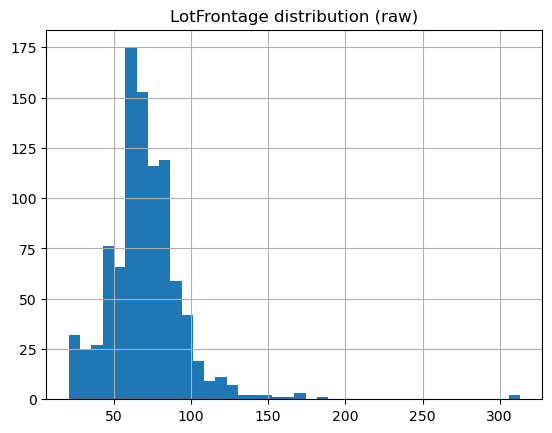

In [40]:
plt.figure()
train["LotFrontage"].hist(bins=40)
plt.title("LotFrontage distribution (raw)")
plt.show()

In [41]:
# Neighborhood별 분포 요약
lf_by_nbhd = (
    train.groupby("Neighborhood")["LotFrontage"]
    .agg(["count", "median", "mean"])
    .sort_values("median")
)

display(lf_by_nbhd.head(15))
display(lf_by_nbhd.tail(15))

,count,median,mean
Neighborhood,,,
BrDale,11,21.0,21.818182
MeadowV,14,21.0,28.285714
Blueste,2,24.0,24.000000
NPkVill,5,24.0,29.800000
Veenker,5,38.0,54.000000
Blmngtn,12,43.0,47.000000
BrkSide,41,52.0,57.512195
IDOTRR,26,60.0,61.769231
OldTown,89,60.0,61.842697


,count,median,mean
Neighborhood,,,
Edwards,71,64.0,69.901408
StoneBr,14,64.5,62.000000
Gilbert,42,65.0,79.761905
SawyerW,41,70.0,72.707317
CollgCr,96,70.0,72.500000
Sawyer,42,70.5,74.119048
Mitchel,27,71.0,73.037037
Crawfor,38,74.5,72.605263
Somerst,65,75.0,65.430769


<br>

#### **Categorical value counts**

In [42]:
for col in ["Street", "Alley", "Utilities"]:
    print(f"\n[{col}] value counts (including NaN)")
    display(train[col].value_counts(dropna=False))


[Street] value counts (including NaN)


Street
Pave    1163
Grvl       5
Name: count, dtype: int64


[Alley] value counts (including NaN)


Alley
NaN     1098
Grvl      37
Pave      33
Name: count, dtype: int64


[Utilities] value counts (including NaN)


Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64

<br>

#### **OverallQual / OverallCond vs y**

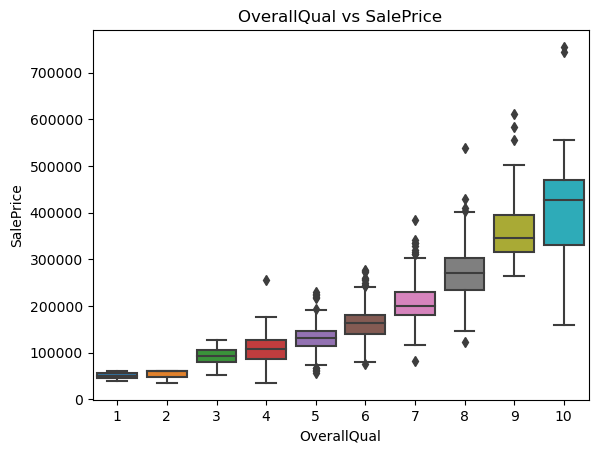

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="OverallQual", y="SalePrice", data=train)
plt.title("OverallQual vs SalePrice")
plt.show()

<br>

#### **YearBuilt / YearRemodAdd 분포**

In [45]:
train[["YearBuilt", "YearRemodAdd"]].describe()

,YearBuilt,YearRemodAdd
count,1168.000000,1168.000000
mean,1971.201199,1985.021404
std,30.362445,20.693264
min,1872.000000,1950.000000
25%,1954.000000,1966.750000
50%,1972.500000,1994.000000
75%,2001.000000,2004.000000
max,2010.000000,2010.000000


In [46]:
((train["YearRemodAdd"] - train["YearBuilt"]) == 0).mean()

0.5256849315068494

<br>

#### **ExterQual / ExterCond value counts**

In [47]:
for col in ["ExterQual", "ExterCond"]:
    print(f"\n[{col}]")
    display(train[col].value_counts())


[ExterQual]


ExterQual
TA    715
Gd    398
Ex     44
Fa     11
Name: count, dtype: int64


[ExterCond]


ExterCond
TA    1019
Gd     120
Fa      25
Ex       3
Po       1
Name: count, dtype: int64

<br>

#### **GrLivArea vs SalePrice (log y)**

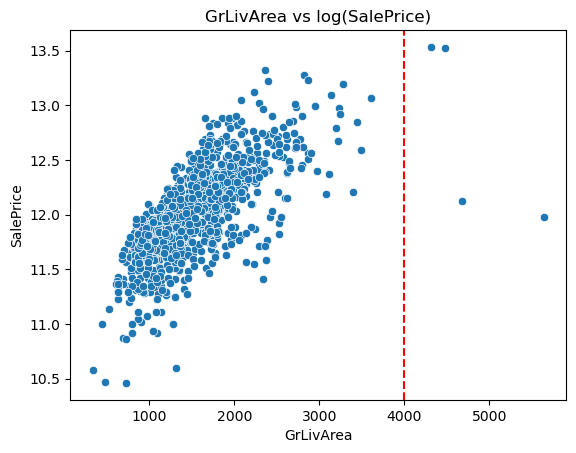

In [48]:
plt.figure()
sns.scatterplot(x="GrLivArea", y=np.log1p(train["SalePrice"]), data=train)
plt.axvline(4000, color="r", linestyle="--")
plt.title("GrLivArea vs log(SalePrice)")
plt.show()

<br>

#### **TotalBsmtSF 분포**

In [49]:
train["TotalBsmtSF"].describe()

count    1168.000000
mean     1060.175514
std       439.223929
min         0.000000
25%       793.000000
50%       990.000000
75%      1306.000000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

<br>

#### **GarageCars vs SalePrice (boxplot)**

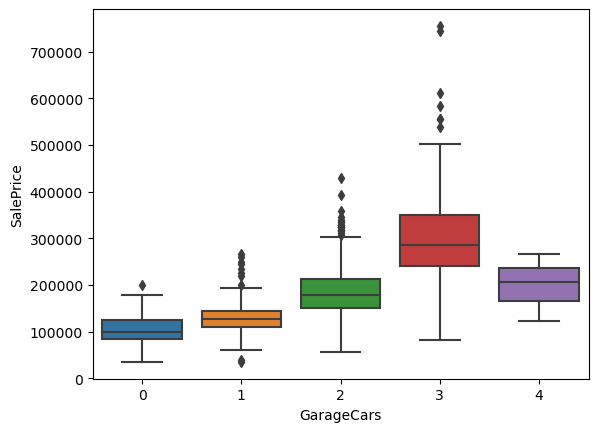

In [50]:
plt.figure()
sns.boxplot(x="GarageCars", y="SalePrice", data=train)
plt.show()

<br>

#### **BsmtQual value counts**

In [51]:
train["BsmtQual"].value_counts(dropna=False)

BsmtQual
TA     523
Gd     501
Ex      91
Fa      30
NaN     23
Name: count, dtype: int64

<br>

### **TASK 3. Data preprocessing & Feature engineering**

In [52]:
# 결측 컬럼만 다시 정리

In [53]:
na_cols = train.columns[train.isna().any()]

summary = []
for col in na_cols:
    summary.append({
        "col": col,
        "dtype": train[col].dtype,
        "train_na": train[col].isna().sum(),
        "test_na": test[col].isna().sum() if col in test.columns else None,
        "unique_vals": train[col].nunique(dropna=True)
    })

na_summary = pd.DataFrame(summary).sort_values("train_na", ascending=False)
na_summary

,col,dtype,train_na,test_na,unique_vals
16,PoolQC,object,1162,291,3
18,MiscFeature,object,1120,286,4
1,Alley,object,1098,271,2
17,Fence,object,941,238,4
2,MasVnrType,object,694,178,3
10,FireplaceQu,object,545,145,5
0,LotFrontage,float64,218,41,104
11,GarageType,object,69,12,6
12,GarageYrBlt,float64,69,12,95
13,GarageFinish,object,69,12,3


#### **None 전용 컬럼 처리 + HasXXX 생성**

In [55]:
# 처리 대상 정의
none_cols_obj = [
    "PoolQC","MiscFeature","Alley","Fence","MasVnrType","FireplaceQu",
    "GarageType","GarageFinish","GarageQual","GarageCond",
    "BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"
]

none_cols_num = [
    "GarageYrBlt","MasVnrArea"
]

In [56]:
# HasXXX 파생 변수 생성
for col in none_cols_obj + none_cols_num:
    train[f"Has_{col}"] = train[col].notna().astype(int)
    test[f"Has_{col}"]  = test[col].notna().astype(int)

In [57]:
# None / 0 채우기
# object → "None"
for col in none_cols_obj:
    train[col] = train[col].fillna("None")
    test[col]  = test[col].fillna("None")

# numeric → 0
for col in none_cols_num:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(0)

#### **LotFrontage**

In [58]:
# Neighborhood 기준 median

In [59]:
lf_map = train.groupby("Neighborhood")["LotFrontage"].median()

train["LotFrontage"] = train.apply(
    lambda x: lf_map[x["Neighborhood"]] if pd.isna(x["LotFrontage"]) else x["LotFrontage"],
    axis=1
)

test["LotFrontage"] = test.apply(
    lambda x: lf_map[x["Neighborhood"]] if pd.isna(x["LotFrontage"]) else x["LotFrontage"],
    axis=1
)

#### **Electrical**

In [60]:
train["Electrical"] = train["Electrical"].fillna(train["Electrical"].mode()[0])

print("Train NaNs:", train.isna().sum().sum())
print("Test  NaNs:", test.isna().sum().sum())

Train NaNs: 0
Test  NaNs: 0


<br>

In [61]:
has_cols = [c for c in train.columns if c.startswith("Has_")]
print(len(has_cols))
print(has_cols)

17
['Has_PoolQC', 'Has_MiscFeature', 'Has_Alley', 'Has_Fence', 'Has_MasVnrType', 'Has_FireplaceQu', 'Has_GarageType', 'Has_GarageFinish', 'Has_GarageQual', 'Has_GarageCond', 'Has_BsmtQual', 'Has_BsmtCond', 'Has_BsmtExposure', 'Has_BsmtFinType1', 'Has_BsmtFinType2', 'Has_GarageYrBlt', 'Has_MasVnrArea']


In [62]:
train[has_cols].mean().sort_values()

Has_PoolQC          0.005137
Has_MiscFeature     0.041096
Has_Alley           0.059932
Has_Fence           0.194349
Has_MasVnrType      0.405822
Has_FireplaceQu     0.533390
Has_GarageCond      0.940925
Has_GarageYrBlt     0.940925
Has_GarageQual      0.940925
Has_GarageType      0.940925
Has_GarageFinish    0.940925
Has_BsmtExposure    0.979452
Has_BsmtFinType2    0.979452
Has_BsmtQual        0.980308
Has_BsmtCond        0.980308
Has_BsmtFinType1    0.980308
Has_MasVnrArea      0.993151
dtype: float64

In [63]:
check_cols = [
    "PoolQC","FireplaceQu","GarageType",
    "BsmtQual","MasVnrType","Fence"
]

for c in check_cols:
    print(f"\n[{c}]")
    print(train[c].value_counts().head(10))


[PoolQC]
PoolQC
None    1162
Gd         2
Ex         2
Fa         2
Name: count, dtype: int64

[FireplaceQu]
FireplaceQu
None    545
Gd      314
TA      246
Fa       27
Ex       20
Po       16
Name: count, dtype: int64

[GarageType]
GarageType
Attchd     690
Detchd     309
BuiltIn     72
None        69
Basment     16
CarPort      9
2Types       3
Name: count, dtype: int64

[BsmtQual]
BsmtQual
TA      523
Gd      501
Ex       91
Fa       30
None     23
Name: count, dtype: int64

[MasVnrType]
MasVnrType
None       694
BrkFace    359
Stone      104
BrkCmn      11
Name: count, dtype: int64

[Fence]
Fence
None     941
MnPrv    127
GdWo      47
GdPrv     46
MnWw       7
Name: count, dtype: int64


In [64]:
print("LotFrontage NaNs:", train["LotFrontage"].isna().sum())
train["LotFrontage"].describe()

LotFrontage NaNs: 0


count    1168.000000
mean       70.203339
std        22.799120
min        21.000000
25%        60.000000
50%        70.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [65]:
train.groupby("Neighborhood")["LotFrontage"].median().head(10)

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    74.5
Edwards    64.0
Gilbert    65.0
IDOTRR     60.0
Name: LotFrontage, dtype: float64

In [66]:
train.loc[
    (train["MasVnrType"]=="None") & (train["MasVnrArea"]!=0),
    ["MasVnrType","MasVnrArea"]
].head()

,MasVnrType,MasVnrArea
615,None,288.0
731,None,1.0
1038,None,1.0
1129,None,312.0


In [67]:
train.dtypes.value_counts()

object     43
int64      35
int32      17
float64     3
Name: count, dtype: int64

<br>

In [68]:
mask = (train["MasVnrType"] == "None")
train.loc[mask, "MasVnrArea"] = 0

mask = (test["MasVnrType"] == "None")
test.loc[mask, "MasVnrArea"] = 0

In [69]:
num_cols_train = train.select_dtypes(include=["int64","int32","float64"]).columns
num_cols_test  = test.select_dtypes(include=["int64","int32","float64"]).columns

# 공통 numeric 컬럼만
num_cols = num_cols_train.intersection(num_cols_test)

train[num_cols] = train[num_cols].astype(float)
test[num_cols]  = test[num_cols].astype(float)

print("casted numeric cols:", len(num_cols))

casted numeric cols: 54


In [70]:
print(train.isna().sum().sum(), test.isna().sum().sum())
print((train.loc[train["MasVnrType"]=="None","MasVnrArea"]>0).sum())
print((test.loc[test["MasVnrType"]=="None","MasVnrArea"]>0).sum())

0 0
0
0


<br>

#### **Ordinal Feature 정밀 인코딩**

In [71]:
# 3-1. Ordinal 컬럼 정의 (의미 순서 기반)

In [72]:
ordinal_maps = {
    # Quality / Condition 계열
    "ExterQual":     {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "ExterCond":     {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "BsmtQual":      {"None":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "BsmtCond":      {"None":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "HeatingQC":     {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "KitchenQual":   {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "FireplaceQu":   {"None":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "GarageQual":    {"None":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "GarageCond":    {"None":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},

    # Finish / Exposure
    "BsmtExposure":  {"None":0, "No":1, "Mn":2, "Av":3, "Gd":4},
    "BsmtFinType1":  {"None":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    "BsmtFinType2":  {"None":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    "GarageFinish":  {"None":0, "Unf":1, "RFn":2, "Fin":3},

    # Functional
    "Functional":    {"Sal":1, "Sev":2, "Maj2":3, "Maj1":4, "Mod":5, "Min2":6, "Min1":7, "Typ":8}
}

In [73]:
# Ordinal Encoding 적용

In [74]:
for col, mapping in ordinal_maps.items():
    if col in train.columns:
        train[col] = train[col].map(mapping).astype(int)
        test[col]  = test[col].map(mapping).astype(int)

print("Ordinal encoding done:", len(ordinal_maps))

Ordinal encoding done: 14


In [75]:
# 안전성 체크

In [76]:
# 혹시 mapping 안 된 값이 남아있는지 확인
for col in ordinal_maps.keys():
    if col in train.columns:
        if train[col].isna().any():
            print("NaN after ordinal:", col)

<br>

#### **핵심 피처 엔지니어링**

In [77]:
# 연식(Age) 파생 변수

In [78]:
# 기준 연도
train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
test["HouseAge"]  = test["YrSold"]  - test["YearBuilt"]

train["RemodAge"] = train["YrSold"] - train["YearRemodAdd"]
test["RemodAge"]  = test["YrSold"]  - test["YearRemodAdd"]

train["IsRemodeled"] = (train["YearBuilt"] != train["YearRemodAdd"]).astype(int)
test["IsRemodeled"]  = (test["YearBuilt"]  != test["YearRemodAdd"]).astype(int)

In [79]:
# 면적 결합 피처

In [80]:
train["TotalSF"] = (
    train["TotalBsmtSF"] +
    train["1stFlrSF"] +
    train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"] +
    test["1stFlrSF"] +
    test["2ndFlrSF"]
)

In [81]:
# 욕실 파생 (가중합)

In [82]:
train["TotalBath"] = (
    train["FullBath"] +
    0.5 * train["HalfBath"] +
    train["BsmtFullBath"] +
    0.5 * train["BsmtHalfBath"]
)

test["TotalBath"] = (
    test["FullBath"] +
    0.5 * test["HalfBath"] +
    test["BsmtFullBath"] +
    0.5 * test["BsmtHalfBath"]
)

In [83]:
# Binary 구조 피처

In [84]:
train["HasBasement"] = (train["TotalBsmtSF"] > 0).astype(int)
test["HasBasement"]  = (test["TotalBsmtSF"]  > 0).astype(int)

train["HasGarage"] = (train["GarageCars"] > 0).astype(int)
test["HasGarage"]  = (test["GarageCars"]  > 0).astype(int)

train["HasFireplace"] = (train["Fireplaces"] > 0).astype(int)
test["HasFireplace"]  = (test["Fireplaces"]  > 0).astype(int)

train["HasPool"] = (train["PoolArea"] > 0).astype(int)
test["HasPool"]  = (test["PoolArea"]  > 0).astype(int)

In [85]:
print(train[["HasBasement","HasGarage","HasFireplace","HasPool"]].mean())
print(test[["HasBasement","HasGarage","HasFireplace","HasPool"]].mean())

HasBasement     0.980308
HasGarage       0.940925
HasFireplace    0.533390
HasPool         0.005137
dtype: float64
HasBasement     0.952055
HasGarage       0.958904
HasFireplace    0.503425
HasPool         0.003425
dtype: float64


<br>

#### **One-Hot Encoding + 정렬(align) → 학습행렬 완성**

In [86]:
# 타깃 분리

In [87]:
y_raw = train["SalePrice"].copy()
y_log = np.log1p(y_raw)

train_X = train.drop(columns=["SalePrice"])
test_X  = test.copy()

In [88]:
# 원-핫 인코딩

In [89]:
train_oh = pd.get_dummies(train_X, drop_first=False)
test_oh  = pd.get_dummies(test_X,  drop_first=False)

In [90]:
# 컬럼 정렬

In [91]:
train_oh, test_oh = train_oh.align(test_oh, join="left", axis=1, fill_value=0)

In [92]:
# 최종 확인

In [93]:
print("X_train:", train_oh.shape)
print("X_test :", test_oh.shape)

assert train_oh.isnull().sum().sum() == 0
assert test_oh.isnull().sum().sum() == 0

X_train: (1168, 265)
X_test : (292, 265)


In [94]:
train_X["GrLivArea"].describe()

count    1168.000000
mean     1511.696062
std       535.707765
min       334.000000
25%      1126.000000
50%      1456.000000
75%      1774.250000
max      5642.000000
Name: GrLivArea, dtype: float64

In [95]:
(train_oh == 0).mean().sort_values(ascending=False).head(10)

RoofMatl_Roll          0.999144
SaleType_Con           0.999144
Electrical_Mix         0.999144
Exterior1st_CBlock     0.999144
Exterior1st_ImStucc    0.999144
RoofMatl_Metal         0.999144
RoofMatl_ClyTile       0.999144
Exterior1st_BrkComm    0.999144
Condition2_PosA        0.999144
RoofStyle_Shed         0.999144
dtype: float64

<br>

#### **이상치 처리(GrLivArea 2개 제거)**

In [96]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index
print("Removed outliers:", len(outliers))

train = train.drop(outliers).reset_index(drop=True)

# 타깃 재정의 (행 수가 바뀌므로)
y_raw = train["SalePrice"].copy()
y_log = np.log1p(y_raw)

print("train shape(after outlier removal):", train.shape)

Removed outliers: 2
train shape(after outlier removal): (1166, 107)


<br>

### **TASK 4. Modeling**

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge

In [100]:
# 필수 객체 체크

In [98]:
required = ["train_oh", "test_oh", "y_log"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"필수 변수 누락: {missing}\n"
                    f"앞에서 one-hot 결과(train_oh/test_oh)와 y_log를 만든 뒤 다시 실행해줘.")

In [101]:
# test_id 확보

In [102]:
if "test" in globals() and "Id" in test.columns:
    test_id = test["Id"].astype(int).values
elif "test_ids" in globals():
    test_id = pd.Series(test_ids).astype(int).values
elif "Id" in test_oh.columns:
    test_id = pd.Series(test_oh["Id"]).astype(int).values
else:
    raise NameError("test의 Id를 찾을 수 없어. test['Id'] 또는 test_ids 변수가 필요해.")

#### **1) Ridge (log target) 학습 & 예측**

In [105]:
assert train_oh.isna().sum().sum() == 0, "train_oh에 NaN 존재"
assert test_oh.isna().sum().sum() == 0, "test_oh에 NaN 존재"

ridge = Pipeline([
    ("scaler", RobustScaler(with_centering=False)),
    ("model", Ridge(alpha=30.0, random_state=42))
])

ridge.fit(train_oh, y_log)
pred_ridge_log = ridge.predict(test_oh)
pred_ridge = np.expm1(pred_ridge_log)
pred_ridge = np.maximum(pred_ridge, 1.0)

print("[Ridge] pred stats:", pd.Series(pred_ridge).describe())

sub_ridge = pd.DataFrame({"Id": test_id, "SalePrice": pred_ridge})
sub_ridge.to_csv("submission_ridge_OH.csv", index=False)
print("Saved: submission_ridge_OH.csv")

<br>

#### **2) CatBoost best 예측 확보**

In [ ]:
candidate_files = [
    # ✅ 여기 맨 위에 "너의 best cat 예측 파일"을 두는 걸 추천
    "submission_cat_native_outlier_removed.csv",
    "submission_ABC_A40_B49_C10.csv",
    "submission_cat_blend_AB.csv",
    "submission_cat_native.csv",
]

pred_cat = None
used_file = None

for fn in candidate_files:
    try:
        tmp = pd.read_csv(fn)
        if set(tmp.columns) >= {"Id", "SalePrice"} and len(tmp) == len(test_id):
            tmp["Id"] = tmp["Id"].astype(int)
            df = pd.DataFrame({"Id": test_id}).merge(tmp[["Id","SalePrice"]], on="Id", how="left")
            if df["SalePrice"].isna().any():
                continue
            pred_cat = df["SalePrice"].values.astype(float)
            used_file = fn
            break
    except Exception:
        pass

if pred_cat is None:
    for varname in ["pred_cat_best", "predA", "pred_test", "pred_test_cat", "pred_cat"]:
        if varname in globals():
            arr = np.array(globals()[varname]).astype(float)
            if arr.shape[0] == len(test_id):
                pred_cat = arr
                used_file = f"(variable: {varname})"
                break

pred_cat = np.maximum(pred_cat, 1.0)
print(f"[Cat] loaded from: {used_file}")
print("[Cat] pred stats:", pd.Series(pred_cat).describe())

<br>

#### **3) Blend (Cat + Ridge) 여러 비율로 제출파일 생성**

In [ ]:
blend_weights = [
    (0.80, 0.20),
    (0.75, 0.25),
    (0.70, 0.30),
    (0.65, 0.35),
    (0.60, 0.40),
]

saved = []
for w_cat, w_ridge in blend_weights:
    pred_blend = w_cat * pred_cat + w_ridge * pred_ridge
    pred_blend = np.maximum(pred_blend, 1.0)

    out_name = f"submission_blend_cat{int(w_cat*100)}_ridge{int(w_ridge*100)}.csv"
    sub = pd.DataFrame({"Id": test_id, "SalePrice": pred_blend})
    sub.to_csv(out_name, index=False)
    saved.append(out_name)

print("\nSaved blend files:")
for s in saved:
    print(" -", s)

In [ ]:
best_guess = "submission_blend_cat65_ridge35.csv"
if best_guess in saved:
    pd.read_csv(best_guess).to_csv("submission_final.csv", index=False)
    print("\nSaved: submission_final.csv  (copy of", best_guess, ")")